# 🛒 E-COMMERCE SALES ANALYTICS
## Objectif :
Analyser les ventes d'une entreprise e-commerce afin de :
- mesurer la performance commerciale
- identifier les produits performants
- analyser les clients
- analyser les tendances temporelles
- produire des recommandations business

## Outils :
> *Python | Pandas | NumPy | Matplotlib | Seaborn*

## 1. IMPORTATION DES LIBRAIRIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


# Configuration générale
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 2. CONFIGURATION DU PROJET

In [2]:
DATA_PATH = Path("../data/data.csv")
OUTPUT_PATH = Path("../outputs")

OUTPUT_PATH.mkdir(exist_ok=True)

## 3. CHARGEMENT DES DONNÉES

In [4]:
df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1"
)

print("Dimensions du dataset :", df.shape)

print("\nAperçu des données :")
df.head()

Dimensions du dataset : (541909, 8)

Aperçu des données :


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 4. EXPLORATION INITIALE

In [11]:
print("\n Informations générales")
df.info()


 Informations générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [12]:
print("\n Statistiques descriptives")
df.describe(include="all").T


 Statistiques descriptives


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
print("\n Valeurs manquantes ")
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]


 Valeurs manquantes 


CustomerID     135080
Description      1454
dtype: int64

In [17]:
print("\n Nombre de doublons")
df.duplicated().sum()


 Nombre de doublons


np.int64(5268)

## 5. NETTOYAGE DES DONNÉES
### 5.1 Suppression des doublons

In [18]:
df = df.drop_duplicates()

print("Après suppression des doublons :", df.shape)

Après suppression des doublons : (536641, 8)


### 5.2 Conversion de la date

In [19]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

### 5.3 Vérification des dates invalides

In [20]:
invalid_dates = df["InvoiceDate"].isna().sum()

print("Dates invalides :", invalid_dates)

Dates invalides : 0


### 5.4 Vérification des quantités

In [21]:
print("\nQuantités négatives :", (df["Quantity"] < 0).sum())

print("Prix négatifs :", (df["UnitPrice"] < 0).sum())


Quantités négatives : 10587
Prix négatifs : 2


In [89]:
df["Revenue"]=df["Quantity"]*df["UnitPrice"]

## 6. TRAITEMENT DES ANNULATIONS

Dans ce dataset, les factures commençant par "C" correspondent généralement aux transactions annulées.


In [90]:
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C")

print("\nNombre de transactions annulées :")
print(df["IsCancelled"].sum())


Nombre de transactions annulées :
9251


In [91]:
# Pour l'analyse commerciale, nous allons travailler
# uniquement sur les ventes positives.

sales = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["IsCancelled"])
].copy()

print("\nDataset après filtrage des ventes :")
print(sales.shape)


Dataset après filtrage des ventes :
(524878, 10)


## 7. TRAITEMENT DES CLIENTS

In [92]:
# Nombre de valeurs manquantes dans CustomerID

print(
    "\nCustomerID manquants :",
    sales["CustomerID"].isna().sum()
)

# Pour les analyses clients, on crée un dataset spécifique
# sans identifiant client manquant.

sales_customer = sales.dropna(
    subset=["CustomerID"]
).copy()


CustomerID manquants : 132186


## 8. FEATURE ENGINEERING

In [93]:
### 8.1 Chiffre d'affaires

sales["Revenue"] = (
    sales["Quantity"] *
    sales["UnitPrice"]
)

In [94]:
### 8.2 Année
sales["Year"] = sales["InvoiceDate"].dt.year

In [95]:
### 8.3 Mois
sales["Month"] = sales["InvoiceDate"].dt.month

In [96]:
### 8.4 Nom du mois
sales["MonthName"] = (
    sales["InvoiceDate"]
    .dt.month_name()
)

In [97]:
### 8.5 Jour
sales["Day"] = sales["InvoiceDate"].dt.day

In [98]:
### 8.6 Jour de la semaine

sales["DayOfWeek"] = (
    sales["InvoiceDate"]
    .dt.day_name()
)

In [99]:
### 8.7 Heure

sales["Hour"] = (
    sales["InvoiceDate"]
    .dt.hour
)

In [100]:
### 8.8 Année-Mois

sales["YearMonth"] = (
    sales["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

## 9. KPI GÉNÉRAUX

In [101]:
total_revenue = sales["Revenue"].sum()

total_orders = sales["InvoiceNo"].nunique()

total_customers = sales["CustomerID"].nunique()

total_products = sales["StockCode"].nunique()

total_quantity = sales["Quantity"].sum()

average_order_value = (
    total_revenue / total_orders
)

In [102]:
print("\n============================")
print("       KPI PRINCIPAUX")
print("==============================")

print(f"Chiffre d'affaires : {total_revenue:,.2f}")

print(f"Nombre de commandes : {total_orders:,}")

print(f"Nombre de clients : {total_customers:,}")

print(f"Nombre de produits : {total_products:,}")

print(f"Quantité vendue : {total_quantity:,}")

print(f"Panier moyen : {average_order_value:,.2f}")


       KPI PRINCIPAUX
Chiffre d'affaires : 10,642,110.80
Nombre de commandes : 19,960
Nombre de clients : 4,338
Nombre de produits : 3,922
Quantité vendue : 5,572,420
Panier moyen : 533.17


## 10. ANALYSE DES VENTES DANS LE TEMPS

In [103]:
monthly_sales = (
    sales
    .groupby("YearMonth", as_index=False)
    ["Revenue"]
    .sum()
)

monthly_sales = monthly_sales.sort_values(
    "YearMonth"
)


print("\n CA mensuel ")
print(monthly_sales)


 CA mensuel 
   YearMonth      Revenue
0    2010-12   821452.730
1    2011-01   689811.610
2    2011-02   522545.560
3    2011-03   716215.260
4    2011-04   536968.491
5    2011-05   769296.610
6    2011-06   760547.010
7    2011-07   718076.121
8    2011-08   757841.380
9    2011-09  1056435.192
10   2011-10  1151263.730
11   2011-11  1503866.780
12   2011-12   637790.330


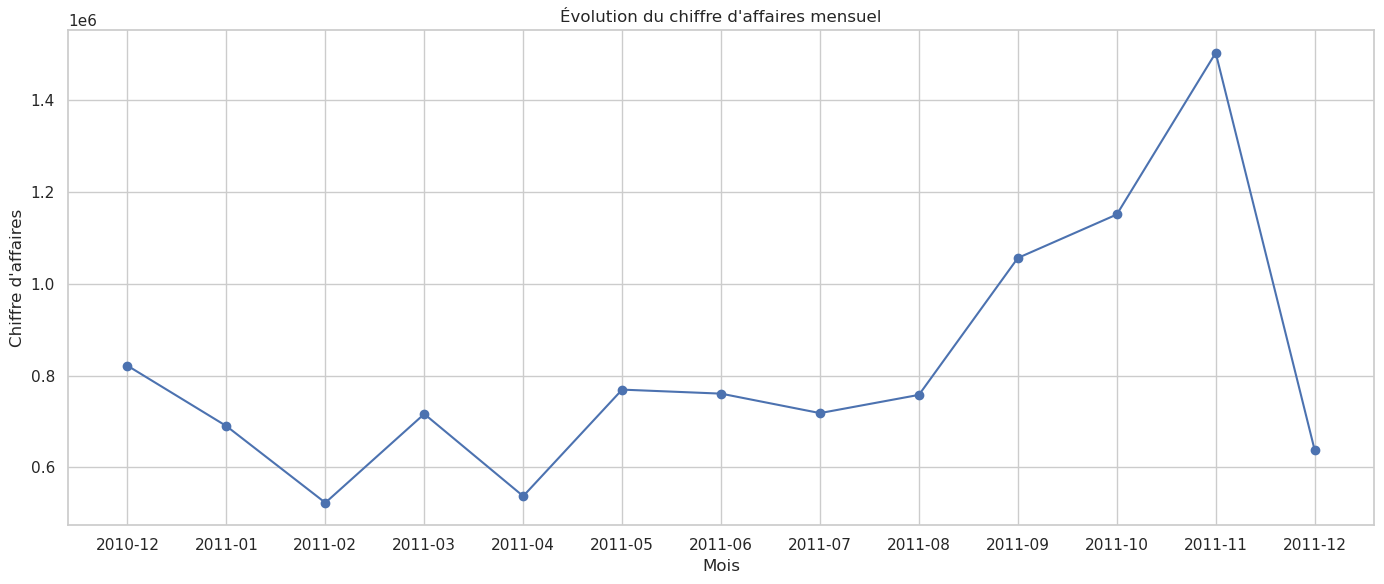

In [79]:
# Visualisation

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Évolution du chiffre d'affaires mensuel")

plt.xlabel("Mois")

plt.ylabel("Chiffre d'affaires")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "monthly_revenue.png",
    dpi=300
)

plt.show()

## 11. ANALYSE DES PRODUITS

In [80]:
product_sales = (
    sales
    .groupby(
        ["StockCode", "Description"],
        as_index=False
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)


In [81]:
## Top 10 produits par chiffre d'affaires

top_products_revenue = (
    product_sales
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(10)
)

In [82]:
print("\n TOP 10 PRODUITS PAR CA")

print(
    top_products_revenue[
        [
            "Description",
            "Revenue",
            "Quantity",
            "Orders"
        ]
    ]
)


 TOP 10 PRODUITS PAR CA
                             Description    Revenue  Quantity  Orders
4150                      DOTCOM POSTAGE  206248.77       706     706
1340            REGENCY CAKESTAND 3 TIER  174156.54     13851    1988
2668         PAPER CRAFT , LITTLE BIRDIE  168469.60     80995       1
3640  WHITE HANGING HEART T-LIGHT HOLDER  104284.24     37580    2189
2877                       PARTY BUNTING   99445.23     18283    1685
3619             JUMBO BAG RED RETROSPOT   94159.81     48371    2089
2123      MEDIUM CERAMIC TOP STORAGE JAR   81700.92     78033     247
4153                             POSTAGE   78101.88      3150    1126
4151                              Manual   77750.27      6984     289
2029                  RABBIT NIGHT LIGHT   66870.03     30739     994


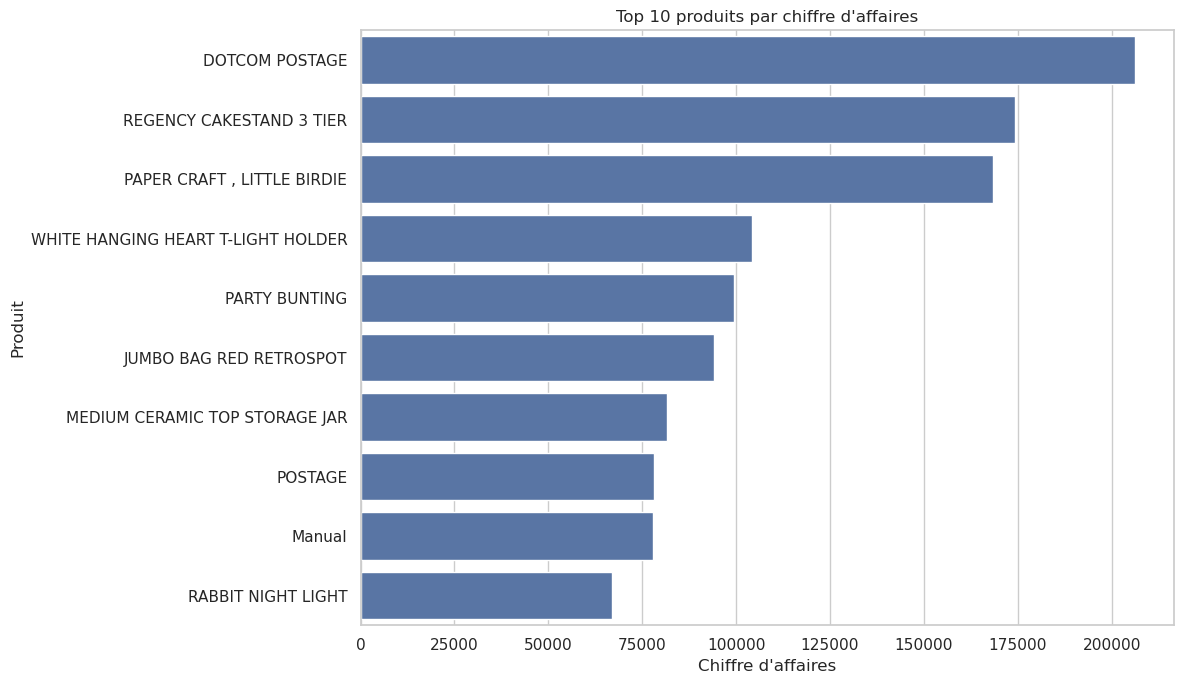

In [83]:
# Visualisation

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description"
)

plt.title(
    "Top 10 produits par chiffre d'affaires"
)

plt.xlabel("Chiffre d'affaires")

plt.ylabel("Produit")

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "top_products_revenue.png",
    dpi=300
)

plt.show()

## 12. PRODUITS LES PLUS VENDUS EN QUANTITÉ

In [84]:

top_products_quantity = (
    product_sales
    .sort_values(
        "Quantity",
        ascending=False
    )
    .head(10)
)


print("\n TOP 10 PRODUITS PAR QUANTITÉ ")

print(
    top_products_quantity[
        [
            "Description",
            "Quantity",
            "Revenue"
        ]
    ]
)


 TOP 10 PRODUITS PAR QUANTITÉ 
                             Description  Quantity    Revenue
2668         PAPER CRAFT , LITTLE BIRDIE     80995  168469.60
2123      MEDIUM CERAMIC TOP STORAGE JAR     78033   81700.92
3128   WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951   13814.01
3619             JUMBO BAG RED RETROSPOT     48371   94159.81
3640  WHITE HANGING HEART T-LIGHT HOLDER     37580  104284.24
1129                      POPCORN HOLDER     36749   34288.67
448      PACK OF 72 RETROSPOT CAKE CASES     36396   21246.45
3416       ASSORTED COLOUR BIRD ORNAMENT     36362   58927.62
2029                  RABBIT NIGHT LIGHT     30739   66870.03
1405             MINI PAINT SET VINTAGE      26633   16937.82


## 13. ANALYSE PAR PAYS

In [85]:
country_sales = (
    sales
    .groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)


print("\n TOP 10 PAYS PAR CA ")

print(
    country_sales.head(10)
)


 TOP 10 PAYS PAR CA 
           Country      Revenue  Orders  Quantity
36  United Kingdom  9001744.094   18019   4646906
24     Netherlands   285446.340      94    200361
10            EIRE   283140.520     288    147007
14         Germany   228678.400     457    119154
13          France   209625.370     392    112060
0        Australia   138453.810      57     83891
31           Spain    61558.560      90     27933
33     Switzerland    57067.600      54     30617
3          Belgium    41196.340      98     23237
32          Sweden    38367.830      36     36078


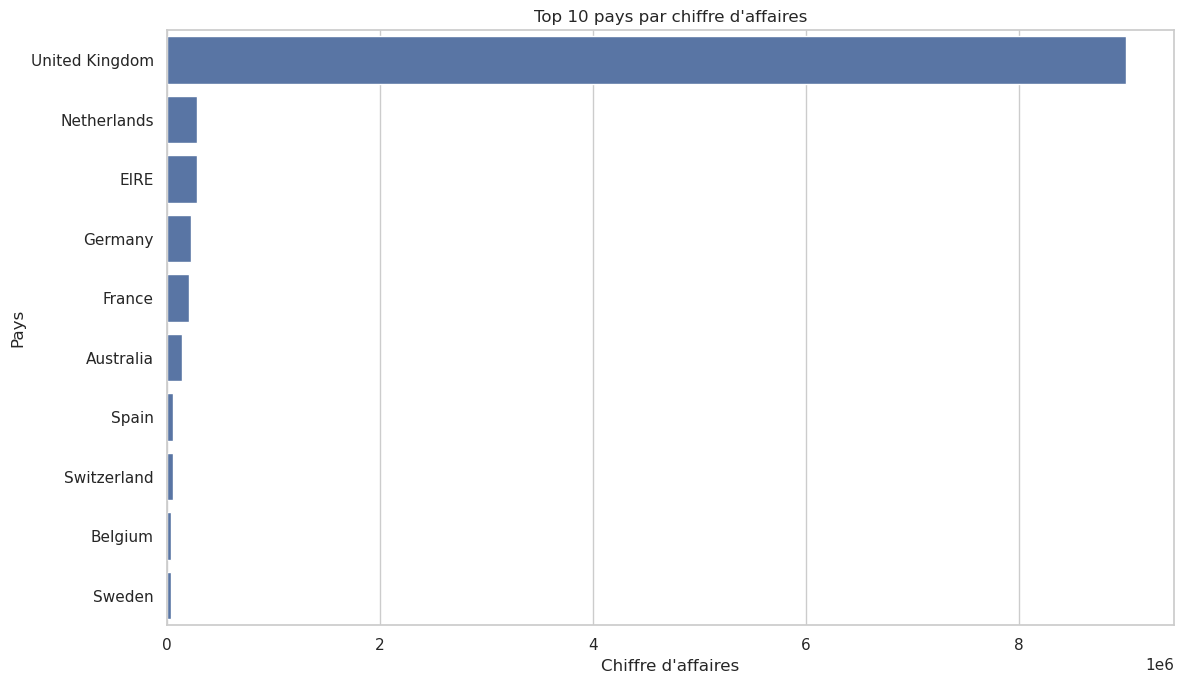

In [86]:
# Visualisation

top_countries = country_sales.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country"
)

plt.title(
    "Top 10 pays par chiffre d'affaires"
)

plt.xlabel("Chiffre d'affaires")

plt.ylabel("Pays")

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "top_countries.png",
    dpi=300
)

plt.show()

## 14. ANALYSE DES CLIENTS

In [104]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'IsCancelled', 'Revenue'],
      dtype='object')

In [105]:
customer_sales = (
    sales_customer
    .groupby("CustomerID", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
)



# Top clients

top_customers = (
    customer_sales
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(10)
)


print("\n TOP 10 CLIENTS")

print(top_customers)


 TOP 10 CLIENTS
      CustomerID    Revenue  Orders  Quantity
1689     14646.0  280206.02      73    196915
4201     18102.0  259657.30      60     64124
3728     17450.0  194390.79      46     69973
3008     16446.0  168472.50       2     80997
1879     14911.0  143711.17     201     80240
55       12415.0  124914.53      21     77374
1333     14156.0  117210.08      55     57768
3771     17511.0   91062.38      31     64549
2702     16029.0   80850.84      63     40108
0        12346.0   77183.60       1     74215


## 15. PANIER MOYEN

In [52]:
order_values = (
    sales
    .groupby("InvoiceNo")["Revenue"]
    .sum()
)

print(
    "\nPanier moyen :",
    order_values.mean()
)

print(
    "Panier médian :",
    order_values.median()
)



Panier moyen : 533.1718839679359
Panier médian : 303.3


## 16. ANALYSE DES JOURS

In [53]:
day_sales = (
    sales
    .groupby("DayOfWeek", as_index=False)
    ["Revenue"]
    .sum()
)


# Ordre correct des jours

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales["DayOfWeek"] = pd.Categorical(
    day_sales["DayOfWeek"],
    categories=day_order,
    ordered=True
)

day_sales = day_sales.sort_values(
    "DayOfWeek"
)

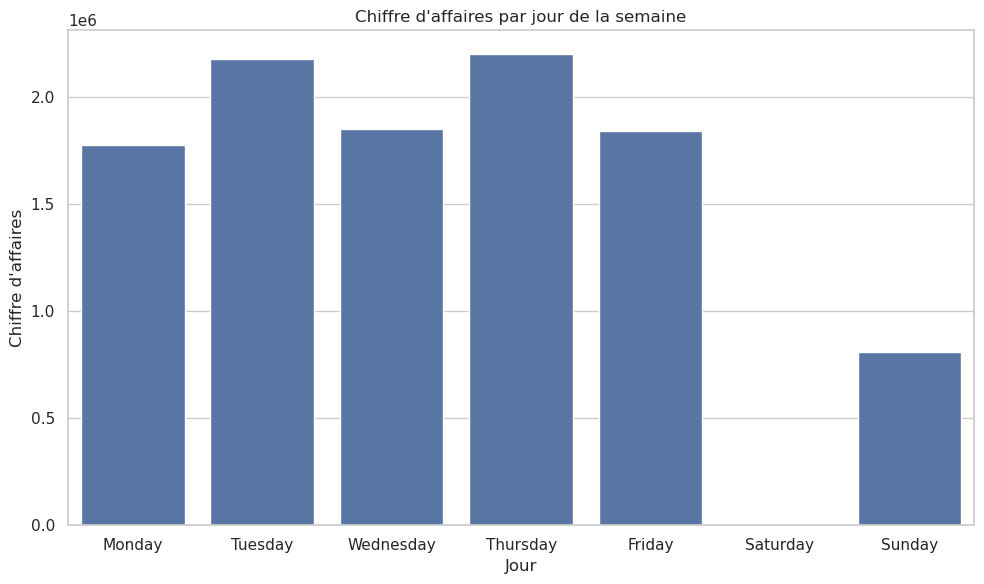

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_sales,
    x="DayOfWeek",
    y="Revenue"
)

plt.title(
    "Chiffre d'affaires par jour de la semaine"
)

plt.xlabel("Jour")

plt.ylabel("Chiffre d'affaires")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "revenue_by_day.png",
    dpi=300
)

plt.show()

## 17. ANALYSE DES HEURES

In [56]:
hour_sales = (
    sales
    .groupby("Hour", as_index=False)
    ["Revenue"]
    .sum()
)


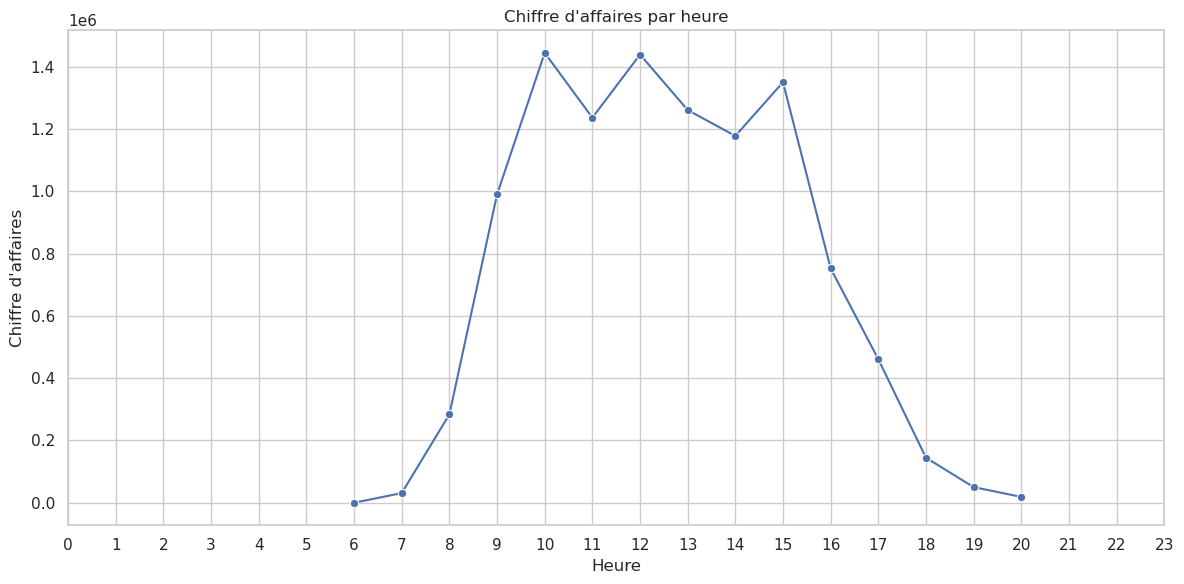

In [57]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_sales,
    x="Hour",
    y="Revenue",
    marker="o"
)

plt.title(
    "Chiffre d'affaires par heure"
)

plt.xlabel("Heure")

plt.ylabel("Chiffre d'affaires")

plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "revenue_by_hour.png",
    dpi=300
)

plt.show()

## 18. ANALYSE DE LA CONTRIBUTION DES PRODUITS

In [58]:
product_sales["RevenueShare"] = (
    product_sales["Revenue"]
    / total_revenue
    * 100
)


top_20_share = (
    product_sales
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(20)["RevenueShare"]
    .sum()
)


print(
    f"\nLes 20 premiers produits représentent "
    f"{top_20_share:.2f}% du chiffre d'affaires."
)


Les 20 premiers produits représentent 15.11% du chiffre d'affaires.


## 19. TABLEAU RÉCAPITULATIF DES KPI

In [60]:
kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Quantity",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_quantity,
        average_order_value
    ]
})


print("\n============================")
print("        KPI SUMMARY")
print("==============================")

print(kpi)


        KPI SUMMARY
                   KPI         Value
0        Total Revenue  1.064211e+07
1         Total Orders  1.996000e+04
2      Total Customers  4.338000e+03
3       Total Products  3.922000e+03
4       Total Quantity  5.572420e+06
5  Average Order Value  5.331719e+02


## 20. EXPORT DES RÉSULTATS

In [106]:
monthly_sales.to_csv(
    OUTPUT_PATH / "monthly_sales.csv",
    index=False
)

product_sales.to_csv(
    OUTPUT_PATH / "product_analysis.csv",
    index=False
)

country_sales.to_csv(
    OUTPUT_PATH / "country_analysis.csv",
    index=False
)

customer_sales.to_csv(
    OUTPUT_PATH / "customer_analysis.csv",
    index=False
)

kpi.to_csv(
    OUTPUT_PATH / "kpi_summary.csv",
    index=False
)


print("\n Analyse terminée avec succès.")
print(f"Résultats disponibles dans : {OUTPUT_PATH}")


 Analyse terminée avec succès.
Résultats disponibles dans : ../outputs
